# Kernel 1: Vector Addition

The first kernel we'll be implementing is vector addition: given two vector $A$ and $B$ in $R^{n}$ compute $C$ such that $c_i = a_i + b_i$ for $i = 0..n-1$

<div style="text-align: center;">
    <img src="assets/add.png" width="500">
</div>

Each FlyDSL kernel has two components:

1. **Kernel code** — defined as a Python function marked with `@flyc.kernel` where we'll actually write our kernel logic using the DSL. Can only be called inside a `@flyc.jit` function.
2. **Launch code** — marked with `@flyc.jit`. Host-side function that launches the kernel, gets jit-compiled on first call.


Let's start by taking the kernel we used earlier to introduce FlyDSL syntax:

In [1]:
import flydsl.compiler as flyc
import flydsl.expr as fx


@flyc.kernel
def add_kernel(A: fx.Pointer, B: fx.Pointer, C: fx.Pointer, ne: fx.Int32):
    idx = fx.thread_idx.x + fx.block_idx.x * fx.block_dim.x
    C[idx] = A[idx] + B[idx]


@flyc.jit
def add(A: fx.Pointer, B: fx.Pointer, C: fx.Pointer, ne: fx.Int32, stream: fx.Stream):
    block_dim = 256
    grid_x = (ne + block_dim - 1) // block_dim
    add_kernel(A, B, C, ne).launch(grid=(grid_x, 1, 1), block=(block_dim, 1, 1), stream=stream)

Now we can call it directly with PyTorch tensors as arguments:

In [2]:
import torch

n = 1024
A = torch.rand(n, device="cuda")
B = torch.rand(n, device="cuda")
C = torch.empty(n, dtype=torch.float32, device="cuda")

add(A, B, C, n, torch.cuda.default_stream())

In [3]:
torch.allclose(C, A + B)

True

## Kernel Breakdown

Now that we know the kernel is correct, let's try to analyze its performance

In [4]:
# Helpers (DO NOT EDIT)
import matplotlib.pyplot as plt


def avg_elapsed_time(fn, *, warmup=10, iters=100):
    """Average elapsed time in seconds of `fn` measured with CUDA events."""
    for _ in range(warmup):
        fn()

    torch.cuda.synchronize()

    start = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)

    latencies = []
    for _ in range(iters):
        start.record()
        fn()
        end.record()
        end.synchronize()
        latencies.append(start.elapsed_time(end) * 1e-3)

    return sum(latencies) / iters

def plot_series(series, *, labels=None, xlabel=None, ylabel=None, title=None):
    """Plot n series, each a list of [x, y] coordinates.

    `series` is a list of series; each series is a list of [x, y] points.
    `labels` optionally names each series for the legend.
    """
    fig, ax = plt.subplots()
    all_xs = sorted({p[0] for s in series for p in s})
    pos = {x: i for i, x in enumerate(all_xs)}
    for i, points in enumerate(series):
        xs = [pos[p[0]] for p in points]
        ys = [p[1] for p in points]
        label = labels[i] if labels is not None else None
        ax.plot(xs, ys, marker="o", label=label)

    ax.set_xticks(range(len(all_xs)))
    ax.set_xticklabels([str(int(x)) for x in all_xs], rotation=45, ha="right")

    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    if title is not None:
        ax.set_title(title)
    if labels is not None:
        ax.legend()

    fig.tight_layout()
    plt.show()

In [5]:
for s in range(10, 29, 1):
    ne = 2 ** s
    A = torch.rand(ne, dtype=torch.float32, device="cuda")
    B = torch.rand(ne, dtype=torch.float32, device="cuda")
    C = torch.empty(ne, dtype=torch.float32, device="cuda")
    elapsed_s = avg_elapsed_time(lambda: add(A, B, C, ne, torch.cuda.default_stream()))
    gbps = (A.nbytes + B.nbytes + C.nbytes) / 1e9 / elapsed_s
    print(f'ne=2^{s} bandwidth={gbps:.1f} GB/s')

ne=2^10 bandwidth=0.1 GB/s
ne=2^11 bandwidth=0.2 GB/s
ne=2^12 bandwidth=0.6 GB/s
ne=2^13 bandwidth=1.2 GB/s
ne=2^14 bandwidth=2.5 GB/s
ne=2^15 bandwidth=4.9 GB/s
ne=2^16 bandwidth=9.8 GB/s
ne=2^17 bandwidth=19.4 GB/s
ne=2^18 bandwidth=39.2 GB/s
ne=2^19 bandwidth=78.5 GB/s
ne=2^20 bandwidth=156.8 GB/s
ne=2^21 bandwidth=319.6 GB/s
ne=2^22 bandwidth=785.3 GB/s
ne=2^23 bandwidth=1727.9 GB/s
ne=2^24 bandwidth=3092.6 GB/s
ne=2^25 bandwidth=3574.2 GB/s
ne=2^26 bandwidth=4399.5 GB/s
ne=2^27 bandwidth=4536.1 GB/s
ne=2^28 bandwidth=4933.1 GB/s


To understand what's going on studying the generated assembly code is very important. In FlyDSL it's easy to get the assembly for any given kernel, just specify the environment variables:

- `FLYDSL_DUMP_IR=1`
- `FLYDSL_DUMP_DIR=<path/you/like>`

The generated code for our vector addition kernel will look something like

```asm
global_load_dword v4, v[2:3], off
global_load_dword v2, v[2:3], off
s_waitcnt vmcnt(0)
v_add_f32_e32 v2, v4, v2
global_store_dword v[0:1], v2, off
s_endpgm
```

Very simple:

1. Load data from global memory to registers
2. Wait for it to be ready
3. Do the addition
4. Store data back into global memory

This means, each thread loads and stores **a single float** from/to global memory at a time. This is not efficient. The solution: loading data in a vectorized way.

### Vectorized Add Kernel

In [10]:
from flydsl.expr.typing import Vector as Vec


@flyc.kernel
def vectorized_add_kernel(A: fx.Pointer, B: fx.Pointer, C: fx.Pointer, ne: fx.Int32):
    class F32x4:
        ir_type = Vec.make_type(4, fx.Float32)

    def _load_v4(src, offset):
        # `recast_iter` is the equivalent of `reinterpret_cast` in C++ land
        # `get_iter` is FlyDSL way of getting a raw pointer for an higher-level type
        ptr = fx.recast_iter(fx.Float32, fx.get_iter(src) + offset)
        # `ptr_load` is the equivalent of an assignment
        #
        # This function could've been written in C++ as `return *reinterpret_cast<float4*>(src)[offset];`
        return fx.ptr_load(ptr, result_type=F32x4)

    idx = fx.thread_idx.x + fx.block_idx.x * fx.block_dim.x

    offset = idx * 4
    a_i = _load_v4(A, offset)
    b_i = _load_v4(B, offset)
    c_i = a_i + b_i

    dst = fx.recast_iter(fx.Float32, fx.get_iter(C) + offset)
    fx.ptr_store(c_i, dst)


@flyc.jit
def vectorized_add(A: fx.Pointer, B: fx.Pointer, C: fx.Pointer, ne: fx.Int32, stream: fx.Stream):
    block_dim = 256
    grid_x = (ne // 4 + block_dim - 1) // block_dim
    vectorized_add_kernel(A, B, C, ne).launch(grid=(grid_x, 1, 1), block=(block_dim, 1, 1), stream=stream)

If we look at the generated assembly for this kernel we'll see something like:
```asm
global_load_dwordx4 v[0:3], v[0:1], off
global_load_dwordx4 v[4:7], v[4:5], off
s_waitcnt vmcnt(0)
v_pk_add_f32 v[2:3], v[2:3], v[6:7]
v_pk_add_f32 v[0:1], v[0:1], v[4:5]
global_store_dwordx4 v[4:5], v[0:3], off
s_endpgm
```

Similar structure, but now the load and store operations are wider.

In [11]:
n = 1024
A = torch.rand(n, device="cuda")
B = torch.rand(n, device="cuda")
C = torch.empty(n, dtype=torch.float32, device="cuda")

vectorized_add(A, B, C, n, torch.cuda.default_stream())

torch.allclose(C, A + B)

True

### Performance Comparison


In [8]:
# Generate 2 series of data: 1 for the scalar and 1 for the vectorized version
data = [[], []]
for s in range(20, 29, 1):
    ne = 2 ** s
    A = torch.rand(ne, dtype=torch.float32, device="cuda")
    B = torch.rand(ne, dtype=torch.float32, device="cuda")
    C = torch.empty(ne, dtype=torch.float32, device="cuda")
    elapsed_s = avg_elapsed_time(lambda: add(A, B, C, ne, torch.cuda.default_stream()))
    gbps = (A.nbytes + B.nbytes + C.nbytes) / 1e9 / elapsed_s
    data[0].append([ne, gbps])
    print(f'[scalar] ne=2^{s} bandwidth={gbps:.1f} GB/s')

for s in range(20, 29, 1):
    ne = 2 ** s
    A = torch.rand(ne, dtype=torch.float32, device="cuda")
    B = torch.rand(ne, dtype=torch.float32, device="cuda")
    C = torch.empty(ne, dtype=torch.float32, device="cuda")
    elapsed_s = avg_elapsed_time(lambda: vectorized_add(A, B, C, ne, torch.cuda.default_stream()))
    gbps = (A.nbytes + B.nbytes + C.nbytes) / 1e9 / elapsed_s
    data[1].append([ne, gbps])
    print(f'[vect] ne=2^{s} bandwidth={gbps:.1f} GB/s')

[scalar] ne=2^20 bandwidth=116.8 GB/s
[scalar] ne=2^21 bandwidth=314.3 GB/s
[scalar] ne=2^22 bandwidth=626.8 GB/s
[scalar] ne=2^23 bandwidth=1164.5 GB/s
[scalar] ne=2^24 bandwidth=2030.7 GB/s
[scalar] ne=2^25 bandwidth=2794.3 GB/s
[scalar] ne=2^26 bandwidth=4150.4 GB/s
[scalar] ne=2^27 bandwidth=4652.7 GB/s
[scalar] ne=2^28 bandwidth=4842.2 GB/s
[vect] ne=2^20 bandwidth=314.4 GB/s
[vect] ne=2^21 bandwidth=654.3 GB/s
[vect] ne=2^22 bandwidth=1211.7 GB/s
[vect] ne=2^23 bandwidth=2079.7 GB/s
[vect] ne=2^24 bandwidth=3280.3 GB/s
[vect] ne=2^25 bandwidth=3876.3 GB/s
[vect] ne=2^26 bandwidth=4715.0 GB/s
[vect] ne=2^27 bandwidth=5050.2 GB/s
[vect] ne=2^28 bandwidth=5663.3 GB/s


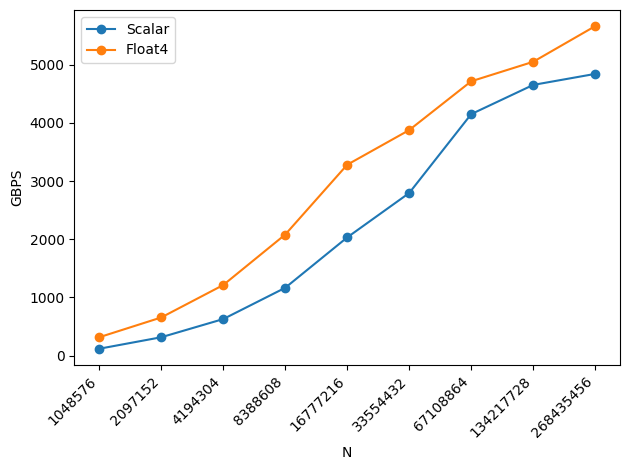

In [9]:
# Plot the data
plot_series(data, labels=["Scalar", "Float4"], xlabel="N", ylabel="GBPS")